<a href="https://colab.research.google.com/github/Ashwin-2408/Tensor_Flow_Learning/blob/main/notebooks/MulitClass_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MultiClass CNN

In [1]:
! wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip

--2025-06-17 12:51:57--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_all_data.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.175.207, 74.125.200.207, 74.125.130.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.175.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 519183241 (495M) [application/zip]
Saving to: ‘10_food_classes_all_data.zip’

10_food_classes_all 100%[===================>] 495.13M  21.6MB/s    in 24s     

2025-06-17 12:52:21 (20.9 MB/s) - ‘10_food_classes_all_data.zip’ saved [519183241/519183241]



In [2]:
import zipfile
zip_ref=zipfile.ZipFile("10_food_classes_all_data.zip")
zip_ref.extractall()
zip_ref.close()

In [3]:
import os

for dirpath,dirnames,filenames in os.walk("/content/10_food_classes_all_data"):
  print(f"there are {len(dirnames)} directories and {len(filenames)} in '{dirpath}'." )

there are 2 directories and 0 in '/content/10_food_classes_all_data'.
there are 10 directories and 0 in '/content/10_food_classes_all_data/train'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/ramen'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/chicken_curry'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/grilled_salmon'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/steak'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/fried_rice'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/sushi'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/chicken_wings'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/pizza'.
there are 0 directories and 750 in '/content/10_food_classes_all_data/train/ice_cream'.
there are 0 directories and 750 in '/content/10_food_classes_al

(512, 512, 3)

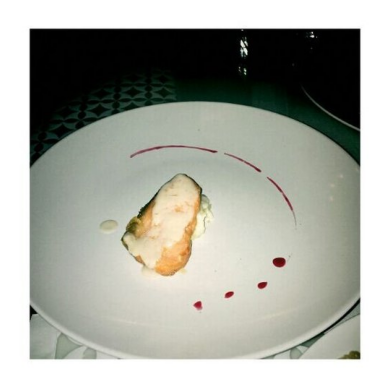

In [4]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
image=mpimg.imread("/content/10_food_classes_all_data/train/grilled_salmon/1002334.jpg")
plt.imshow(image)
plt.axis("off")
image.shape


In [5]:
class_names=["ice_cream","ramen","fried_rice","hamburger","chicken_wings","sushi","chicken_curry","pizza","grilled_salmon","steak"]

## Creating a function to view the different classes and their images along with analyzing their shapes.

In [6]:
import random
def view_image(target,class_names):
  random_class=random.randint(0,len(class_names)-1)
  target_directory=target+"/"+class_names[random_class]
  file_names=os.listdir(target_directory)
  random_image=random.randint(0,len(file_names)-1)
  target_image=target_directory+"/"+file_names[random_image]
  image=mpimg.imread(target_image)
  print(image.shape)
  plt.imshow(image)
  plt.axis(False)
  plt.title(class_names[random_class])

(512, 384, 3)


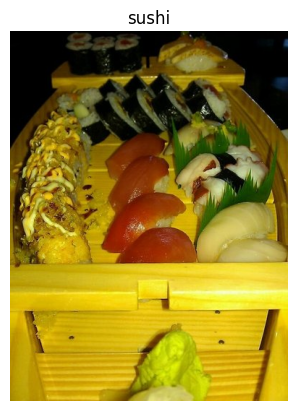

In [7]:
view_image("/content/10_food_classes_all_data/train",class_names)

##Preprocessing the Data


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
train_data_gen=ImageDataGenerator(rescale=1/255.)
test_data_gen=ImageDataGenerator(rescale=1/255.)

#loading data from directories and converting them in to batches

Train_Data=train_data_gen.flow_from_directory("/content/10_food_classes_all_data/train",target_size=(224,224),class_mode="categorical",batch_size=32)
Test_Data=test_data_gen.flow_from_directory("/content/10_food_classes_all_data/test",target_size=(224,224),class_mode="categorical",batch_size=32)

Found 7500 images belonging to 10 classes.
Found 2500 images belonging to 10 classes.


## Creating a MultiClass CNN  Model

In [10]:
import tensorflow as tf
import numpy as np
import random


random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)


Model_v1=tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,kernel_size=3,input_shape=(224,224,3),padding='valid',activation="relu"),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10,activation="softmax")
    ])

Model_v1.compile(loss=tf.keras.losses.CategoricalCrossentropy(),optimizer=tf.keras.optimizers.Adam(),metrics=["accuracy"])

history_1=Model_v1.fit(Train_Data,epochs=5,steps_per_epoch=len(Train_Data),validation_data=Test_Data,validation_steps=len(Test_Data))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


235/235 ━━━━━━━━━━━━━━━━━━━━ 37s 132ms/step - accuracy: 0.1600 - loss: 2.2296 - val_accuracy: 0.3312 - val_loss: 1.9024
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 33s 114ms/step - accuracy: 0.3815 - loss: 1.8145 - val_accuracy: 0.3684 - val_loss: 1.8305
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 26s 109ms/step - accuracy: 0.5837 - loss: 1.2870 - val_accuracy: 0.3428 - val_loss: 2.0450
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 128ms/step - accuracy: 0.8238 - loss: 0.5872 - val_accuracy: 0.3200 - val_loss: 2.7287
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 37s 112ms/step - accuracy: 0.9578 - loss: 0.1726 - val_accuracy: 0.2828 - val_loss: 3.9433


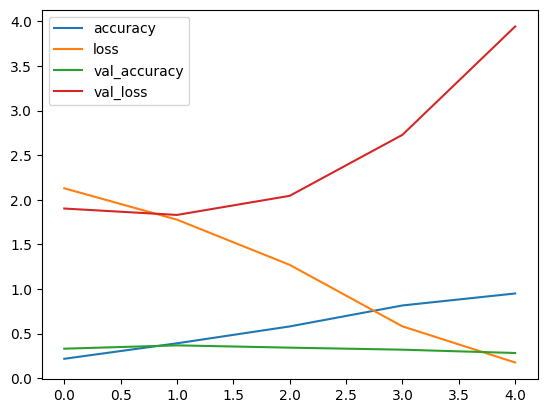

In [12]:
import pandas as pd
pd.DataFrame(history_1.history).plot()
plt.show()

Our model is overfitting

## Adjusting Model HyperParameters to improve the Baseline Model

In [13]:
import tensorflow as tf
import numpy as np
import random


random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)


Model_v2=tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=10,kernel_size=3,input_shape=(224,224,3),padding='valid',activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Conv2D(10,3,activation="relu"),
    tf.keras.layers.MaxPool2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(10,activation="softmax")
    ])

Model_v2.compile(loss=tf.keras.losses.CategoricalCrossentropy(),optimizer=tf.keras.optimizers.Adam(),metrics=["accuracy"])

history_2=Model_v2.fit(Train_Data,epochs=5,steps_per_epoch=len(Train_Data),validation_data=Test_Data,validation_steps=len(Test_Data))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 30s 114ms/step - accuracy: 0.1761 - loss: 2.3393 - val_accuracy: 0.3152 - val_loss: 1.9691
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.3864 - loss: 1.8245 - val_accuracy: 0.3296 - val_loss: 1.9429
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 40s 103ms/step - accuracy: 0.5346 - loss: 1.4479 - val_accuracy: 0.3308 - val_loss: 1.9780
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 44s 116ms/step - accuracy: 0.7152 - loss: 0.9680 - val_accuracy: 0.2972 - val_loss: 2.2601
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 106ms/step - accuracy: 0.8465 - loss: 0.5760 - val_accuracy: 0.2828 - val_loss: 2.7542


In [17]:
Model_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       280,910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 851,762 (3.25 MB)

 Trainable params: 283,920 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 567,842 (2.17 MB)

In [16]:
Model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 29160)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │       291,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 878,402 (3.35 MB)

 Trainable params: 292,800 (1.12 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 585,602 (2.23 MB)

Reducing the number of layers has decreased the accuracy of our model . Lets try data augmentation.

In [18]:
Augmented_Data_Generator=ImageDataGenerator(rescale=1/255.,width_shift_range=.3,height_shift_range=.3,shear_range=.2,zoom_range=.2,horizontal_flip=True)
Augmented_Data=Augmented_Data_Generator.flow_from_directory("/content/10_food_classes_all_data/train",batch_size=32,target_size=(224,224),class_mode="categorical")

Found 7500 images belonging to 10 classes.


Fitting our second model with the augmented data

In [19]:
history_3=Model_v2.fit(Augmented_Data,epochs=5,steps_per_epoch=len(Augmented_Data),validation_data=Test_Data,validation_steps=len(Test_Data))

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 109s 463ms/step - accuracy: 0.2035 - loss: 2.3821 - val_accuracy: 0.2788 - val_loss: 2.0549
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 102s 435ms/step - accuracy: 0.2483 - loss: 2.1376 - val_accuracy: 0.3420 - val_loss: 1.9138
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 141s 432ms/step - accuracy: 0.2765 - loss: 2.0690 - val_accuracy: 0.3628 - val_loss: 1.8764
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 104s 444ms/step - accuracy: 0.2900 - loss: 2.0548 - val_accuracy: 0.3492 - val_loss: 1.8927
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 100s 428ms/step - accuracy: 0.3006 - loss: 2.0255 - val_accuracy: 0.3924 - val_loss: 1.8212


WE can see that our model has performed much better than the previous models.